In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [5]:
df = pd.read_csv("/content/archive (8).zip")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [7]:
print("Data Types:")
print(df.dtypes)

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [8]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [10]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


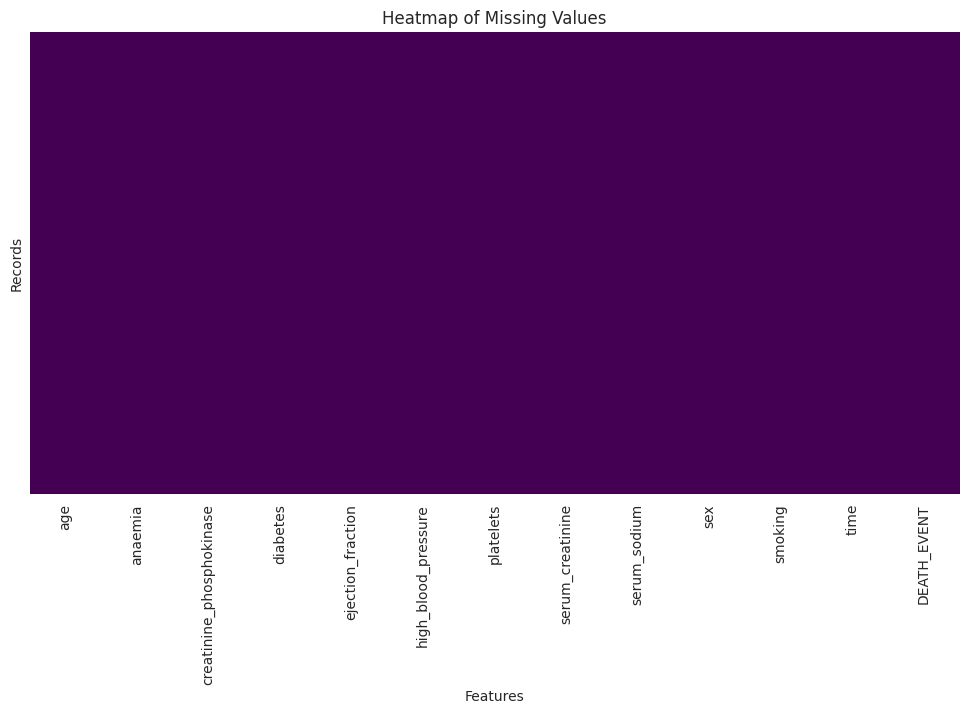

In [11]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap="viridis")

plt.title("Heatmap of Missing Values")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

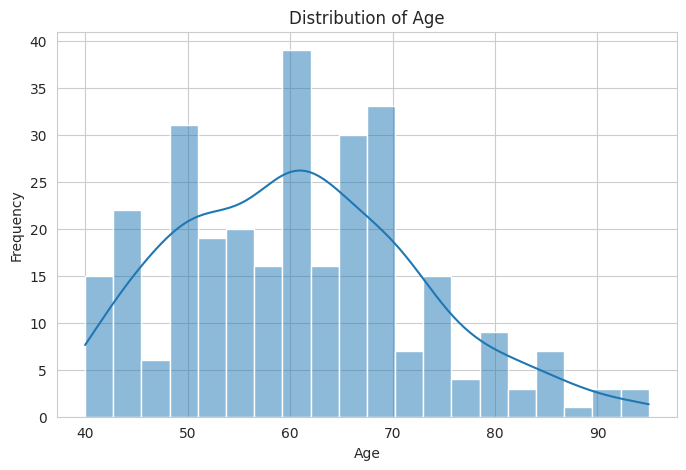

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

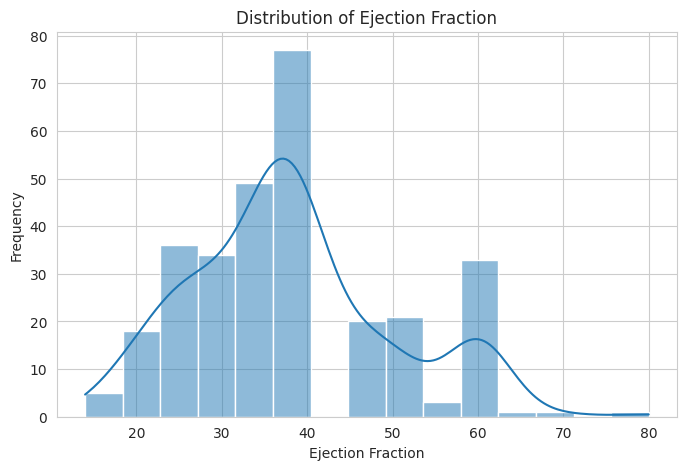

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df['ejection_fraction'], bins=15, kde=True)

plt.title("Distribution of Ejection Fraction")
plt.xlabel("Ejection Fraction")
plt.ylabel("Frequency")

plt.show()

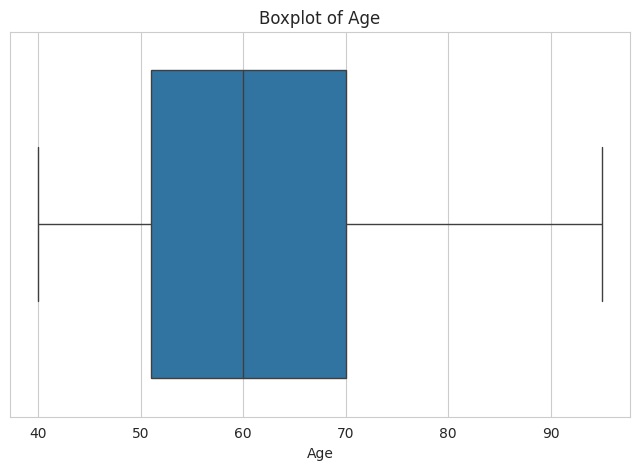

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['age'])

plt.title("Boxplot of Age")
plt.xlabel("Age")

plt.show()

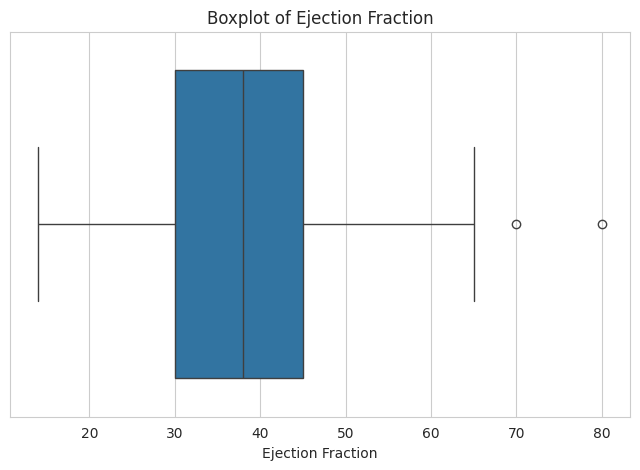

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['ejection_fraction'])

plt.title("Boxplot of Ejection Fraction")
plt.xlabel("Ejection Fraction")

plt.show()

In [16]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking'
]

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Categorical Columns:
['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


In [17]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [18]:
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [19]:
print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [21]:
outlier_columns = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

In [22]:
df_before_outlier_removal = df.copy()

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print("Shape before outlier removal:",
      df_before_outlier_removal.shape)

print("Shape after outlier removal:",
      df.shape)

Shape before outlier removal: (299, 13)
Shape after outlier removal: (224, 13)


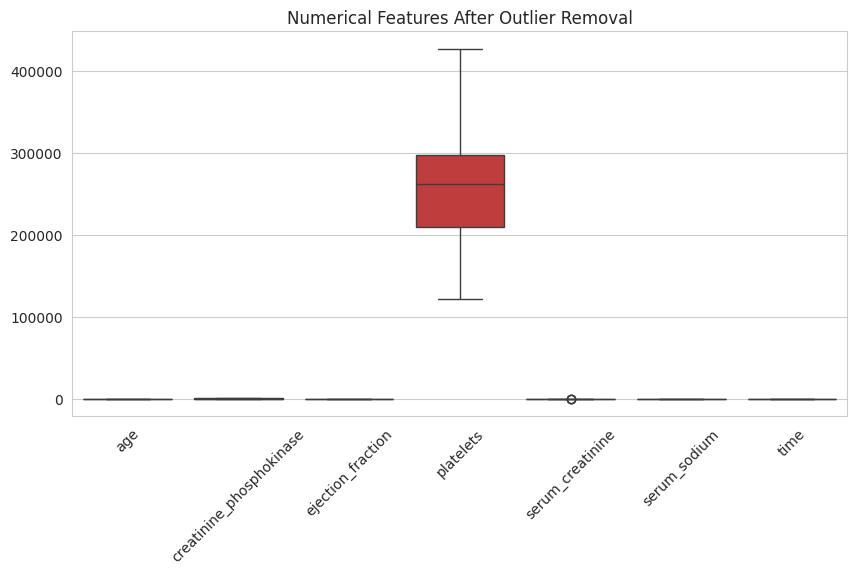

In [23]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[outlier_columns])

plt.xticks(rotation=45)
plt.title("Numerical Features After Outlier Removal")

plt.show()

In [24]:
print("Negative ages:")
print(df[df['age'] < 0])

Negative ages:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [25]:
print("Age less than 0:", (df['age'] < 0).sum())
print("Ejection fraction less than 0:", (df['ejection_fraction'] < 0).sum())
print("Serum creatinine less than 0:", (df['serum_creatinine'] < 0).sum())
print("Serum sodium less than 0:", (df['serum_sodium'] < 0).sum())
print("Platelets less than 0:", (df['platelets'] < 0).sum())

Age less than 0: 0
Ejection fraction less than 0: 0
Serum creatinine less than 0: 0
Serum sodium less than 0: 0
Platelets less than 0: 0


In [26]:
df = df[df['age'] >= 0]

In [27]:
df = df[df['ejection_fraction'] >= 0]
df = df[df['serum_creatinine'] >= 0]
df = df[df['serum_sodium'] >= 0]
df = df[df['platelets'] >= 0]

In [28]:
def create_age_group(age):
    if age < 40:
        return '<40'
    elif age <= 60:
        return '40-60'
    else:
        return '>60'

df['age_group'] = df['age'].apply(create_age_group)

df[['age', 'age_group']].head(10)

,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [29]:
print(df['age_group'].value_counts())


age_group
40-60    115
>60      109
Name: count, dtype: int64


In [30]:
df['risk_score_raw'] = (
    df['ejection_fraction'] *
    df['serum_creatinine']
)

In [31]:
risk_min = df['risk_score_raw'].min()
risk_max = df['risk_score_raw'].max()

df['risk_score'] = (
    (df['risk_score_raw'] - risk_min) /
    (risk_max - risk_min)
)

df[['ejection_fraction',
   'serum_creatinine',
   'risk_score']].head(10)

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
2,20,1.3,0.171495
3,20,1.9,0.310545
5,40,2.1,0.843569
6,15,1.2,0.078795
8,65,1.5,1.000000
11,25,0.9,0.130939
12,30,1.1,0.252607
13,38,1.1,0.354577
14,30,1.0,0.217845


In [32]:
df.drop('risk_score_raw', axis=1, inplace=True)

In [33]:
df = pd.get_dummies(
    df,
    columns=['age_group'],
    drop_first=True
)

In [34]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.310545,True
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.171495,True
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.310545,False
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.843569,True
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.078795,True


In [35]:
features_to_scale = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time',
    'risk_score'
]

In [36]:
scaler = MinMaxScaler()

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

In [37]:
df[features_to_scale].head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000,0.310545
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676,0.171495
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676,0.310545
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235,0.843569
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352,0.078795


In [38]:
df_before_outlier_removal

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [39]:
before_stats = df_before_outlier_removal[
    features_to_scale[:-1]
].agg(['mean', 'median', 'std'])

print("Statistics Before Cleaning:")
display(before_stats)

Statistics Before Cleaning:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
median,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208


In [40]:
after_stats = df[features_to_scale].agg(
    ['mean', 'median', 'std']
)

print("Statistics After Cleaning and Normalization:")
display(after_stats)

Statistics After Cleaning and Normalization:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
mean,0.378355,0.261896,0.474090,0.438902,0.352381,0.523680,0.457836,0.360744
median,0.363636,0.155290,0.470588,0.460656,0.333333,0.521739,0.412811,0.319235
std,0.217202,0.238499,0.229624,0.220176,0.218530,0.165510,0.272526,0.187138


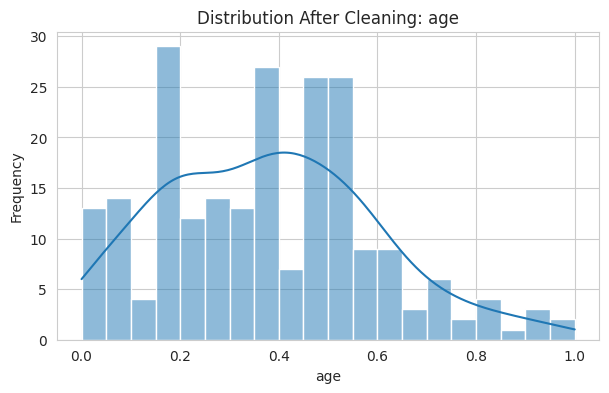

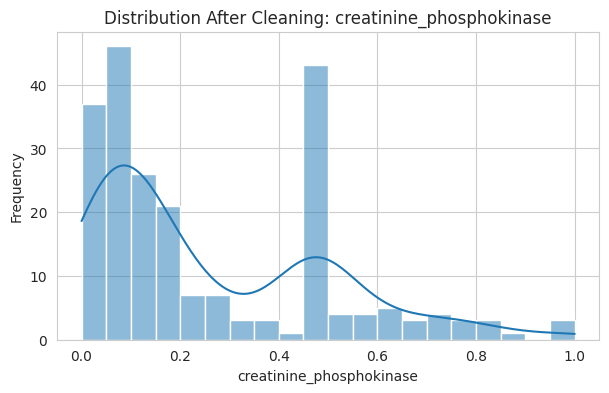

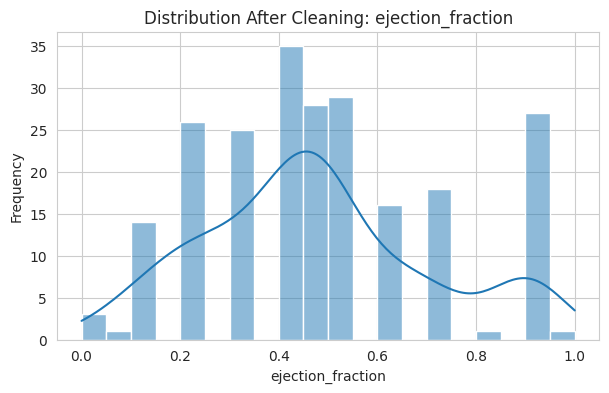

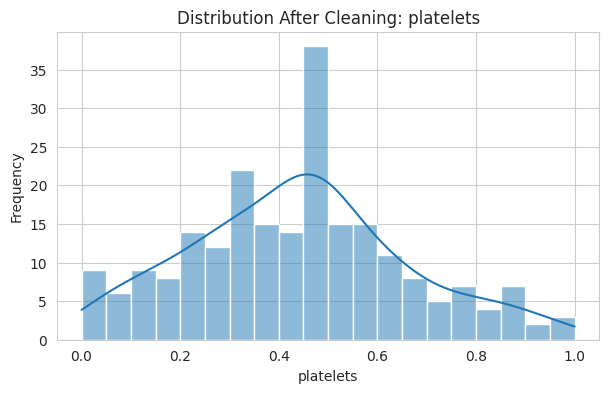

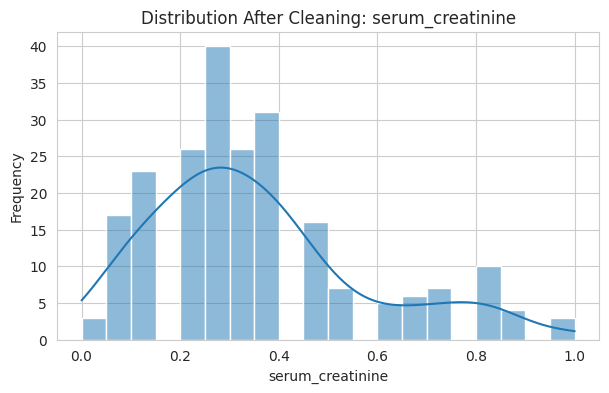

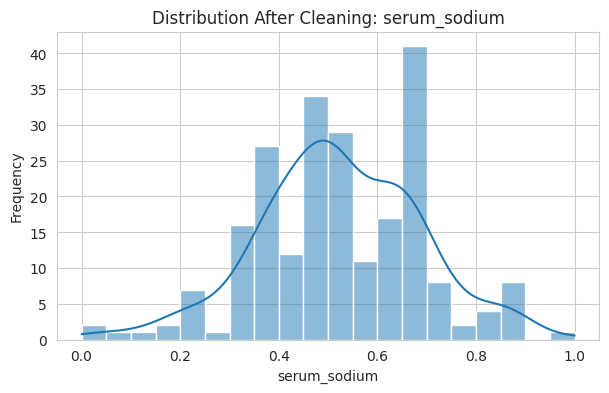

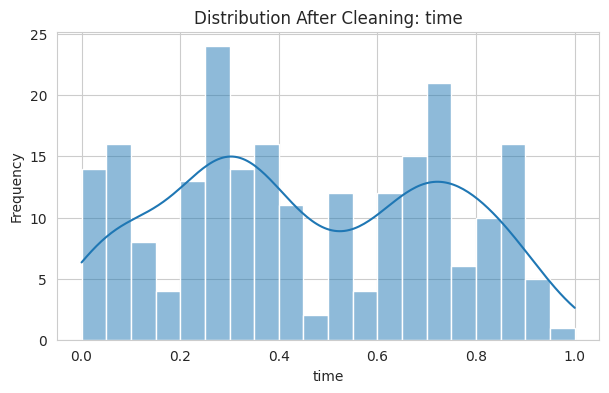

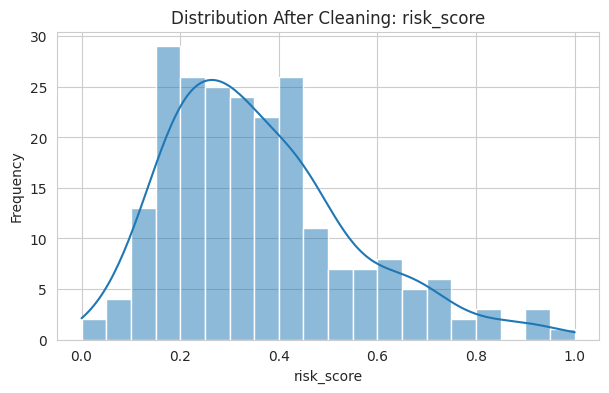

In [41]:
for column in features_to_scale:

    plt.figure(figsize=(7, 4))

    sns.histplot(df[column], bins=20, kde=True)

    plt.title(f"Distribution After Cleaning: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

In [42]:
print("Final Missing Value Check:")
print(df.isnull().sum())

Final Missing Value Check:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_>60               0
dtype: int64


In [43]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values remain. Dataset cleaning is complete.")
else:
    print("Some missing values still remain.")

Total missing values: 0
No missing values remain. Dataset cleaning is complete.


In [44]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Dataset Columns:")
print(df.columns.tolist())

print("\nFinal Dataset:")
display(df.head())

Final Dataset Shape: (224, 15)

Final Dataset Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_>60']

Final Dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.310545,True
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.171495,True
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.310545,False
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.843569,True
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.078795,True


In [45]:
df.to_csv(
    "cleaned_heart_failure_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [46]:
from google.colab import files

files.download("cleaned_heart_failure_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>